# Polarization-index trajectories

This notebook calculates the polarization index μ from the response fractions used in the response-trajectory plots. For each framing, beta, `p_anti`, and round, the response fractions are first averaged across `nid`; μ is then calculated from those three fractions.

The index is defined as

$$\mu = 1 - \frac{|c_{-1} - c_1|}{2} \left(\frac{c_1}{c_0+c_1} + \frac{c_{-1}}{c_0+c_{-1}}\right).$$

When a denominator is zero, its corresponding ratio is set to zero.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
import numpy as np
import pandas as pd

%config InlineBackend.figure_format = 'retina'

DATA_PATH = Path('../Clean_files/07_combined_classified.csv')
RESPONSE_LEVELS = [-1, 0, 1]
BETA_LEVELS = [0.0, 0.5]
FRAMING_LEVELS = [2, 1]
P_ANTI_LEVELS = [99.0, 0.0, 0.5, 1.0]
REQUIRED_COLUMNS = ['round_no', 'response', 'framing', 'beta', 'p_anti', 'nid']


In [2]:
df = pd.read_csv(DATA_PATH, sep=',', usecols=REQUIRED_COLUMNS)
plot_data = df.loc[
    df['framing'].isin(FRAMING_LEVELS)
    & df['beta'].isin(BETA_LEVELS)
    & df['p_anti'].isin(P_ANTI_LEVELS)
    & df['response'].isin(RESPONSE_LEVELS),
    REQUIRED_COLUMNS,
].copy()
print(f'Rows used: {len(plot_data):,}')
print(f'Framing levels: {sorted(plot_data.framing.unique())}')
print(f'Rounds: {plot_data.round_no.min()}–{plot_data.round_no.max()}')
display(plot_data.head())

Rows used: 29,211
Framing levels: [np.int64(1), np.int64(2)]
Rounds: 0–20


,round_no,response,framing,beta,p_anti,nid
0,0,-1.0,1,0.5,0.5,1
1,1,-1.0,1,0.5,0.5,1
2,2,-1.0,1,0.5,0.5,1
3,3,-1.0,1,0.5,0.5,1
4,4,1.0,1,0.5,0.5,1


## Calculate response fractions and μ

In [3]:
group_columns = ['framing', 'beta', 'p_anti', 'nid', 'round_no']
nid_fractions = (
    plot_data.groupby(group_columns)['response']
    .value_counts(normalize=True)
    .unstack('response', fill_value=0)
    .reindex(columns=RESPONSE_LEVELS, fill_value=0)
    .rename_axis(columns='response')
    .stack(future_stack=True)
    .rename('fraction')
    .reset_index()
)

mean_fractions = (
    nid_fractions.groupby(
        ['framing', 'beta', 'p_anti', 'round_no', 'response'], as_index=False
    )['fraction']
    .mean()
    .rename(columns={'fraction': 'mean_fraction'})
)

fraction_table = (
    mean_fractions.pivot(
        index=['framing', 'beta', 'p_anti', 'round_no'],
        columns='response', values='mean_fraction'
    )
    .reindex(columns=RESPONSE_LEVELS, fill_value=0)
    .rename(columns={-1: 'c_minus_1', 0: 'c_0', 1: 'c_1'})
    .reset_index()
)

def safe_ratio(numerator, denominator):
    return np.divide(
        numerator, denominator, out=np.zeros_like(numerator, dtype=float),
        where=denominator != 0,
    )

c_minus_1 = fraction_table['c_minus_1'].to_numpy()
c_0 = fraction_table['c_0'].to_numpy()
c_1 = fraction_table['c_1'].to_numpy()
fraction_table['mu'] = (
    (1 - np.abs(c_minus_1 - c_1) )/ 2
    * (
        safe_ratio(c_1, c_0 + c_1)
        + safe_ratio(c_minus_1, c_0 + c_minus_1)
    )
)
print(f'μ values: min={fraction_table["mu"].min():.4f}, max={fraction_table["mu"].max():.4f}')
assert fraction_table['mu'].between(0, 1).all()
display(fraction_table.head())

# Calculate μ for each nid first; these values provide the SEM confidence intervals.
nid_fraction_table = (
    nid_fractions.pivot(
        index=['framing', 'beta', 'p_anti', 'nid', 'round_no'],
        columns='response', values='fraction'
    )
    .reindex(columns=RESPONSE_LEVELS, fill_value=0)
    .rename(columns={-1: 'c_minus_1', 0: 'c_0', 1: 'c_1'})
)
nid_c_minus_1 = nid_fraction_table['c_minus_1'].to_numpy()
nid_c_0 = nid_fraction_table['c_0'].to_numpy()
nid_c_1 = nid_fraction_table['c_1'].to_numpy()
nid_fraction_table['mu'] = (
    (1 - np.abs(nid_c_minus_1 - nid_c_1) )/ 2
    * (
        safe_ratio(nid_c_1, nid_c_0 + nid_c_1)
        + safe_ratio(nid_c_minus_1, nid_c_0 + nid_c_minus_1)
    )
)

polarization = (
    nid_fraction_table.reset_index()
    .groupby(['framing', 'beta', 'p_anti', 'round_no'], as_index=False)
    .agg(
        mean_mu=('mu', 'mean'),
        sem_mu=('mu', 'sem'),
        n_nid=('nid', 'nunique'),
    )
)
polarization['ci95'] = 1.96 * polarization['sem_mu']
polarization['ci_lower'] = (polarization['mean_mu'] - polarization['ci95']).clip(lower=0)
polarization['ci_upper'] = (polarization['mean_mu'] + polarization['ci95']).clip(upper=1)
assert polarization['mean_mu'].between(0, 1).all()
display(polarization.head())

μ values: min=0.1138, max=1.0000


response,framing,beta,p_anti,round_no,c_minus_1,c_0,c_1,mu
0,1,0.0,0.0,0,0.5000,0.0000,0.5000,1.000000
1,1,0.0,0.0,1,0.4875,0.0250,0.4875,0.951220
2,1,0.0,0.0,2,0.4625,0.0125,0.5250,0.914263
3,1,0.0,0.0,3,0.4875,0.0250,0.4875,0.951220
4,1,0.0,0.0,4,0.4750,0.0250,0.5000,0.927411


,framing,beta,p_anti,round_no,mean_mu,sem_mu,n_nid,ci95,ci_lower,ci_upper
0,1,0.0,0.0,0,1.000000,0.000000,10,0.000000,1.000000,1.0
1,1,0.0,0.0,1,0.935625,0.042917,10,0.084117,0.851508,1.0
2,1,0.0,0.0,2,0.917812,0.042303,10,0.082913,0.834899,1.0
3,1,0.0,0.0,3,0.935625,0.042917,10,0.084117,0.851508,1.0
4,1,0.0,0.0,4,0.935625,0.042917,10,0.084117,0.851508,1.0


## Plot μ for both framings

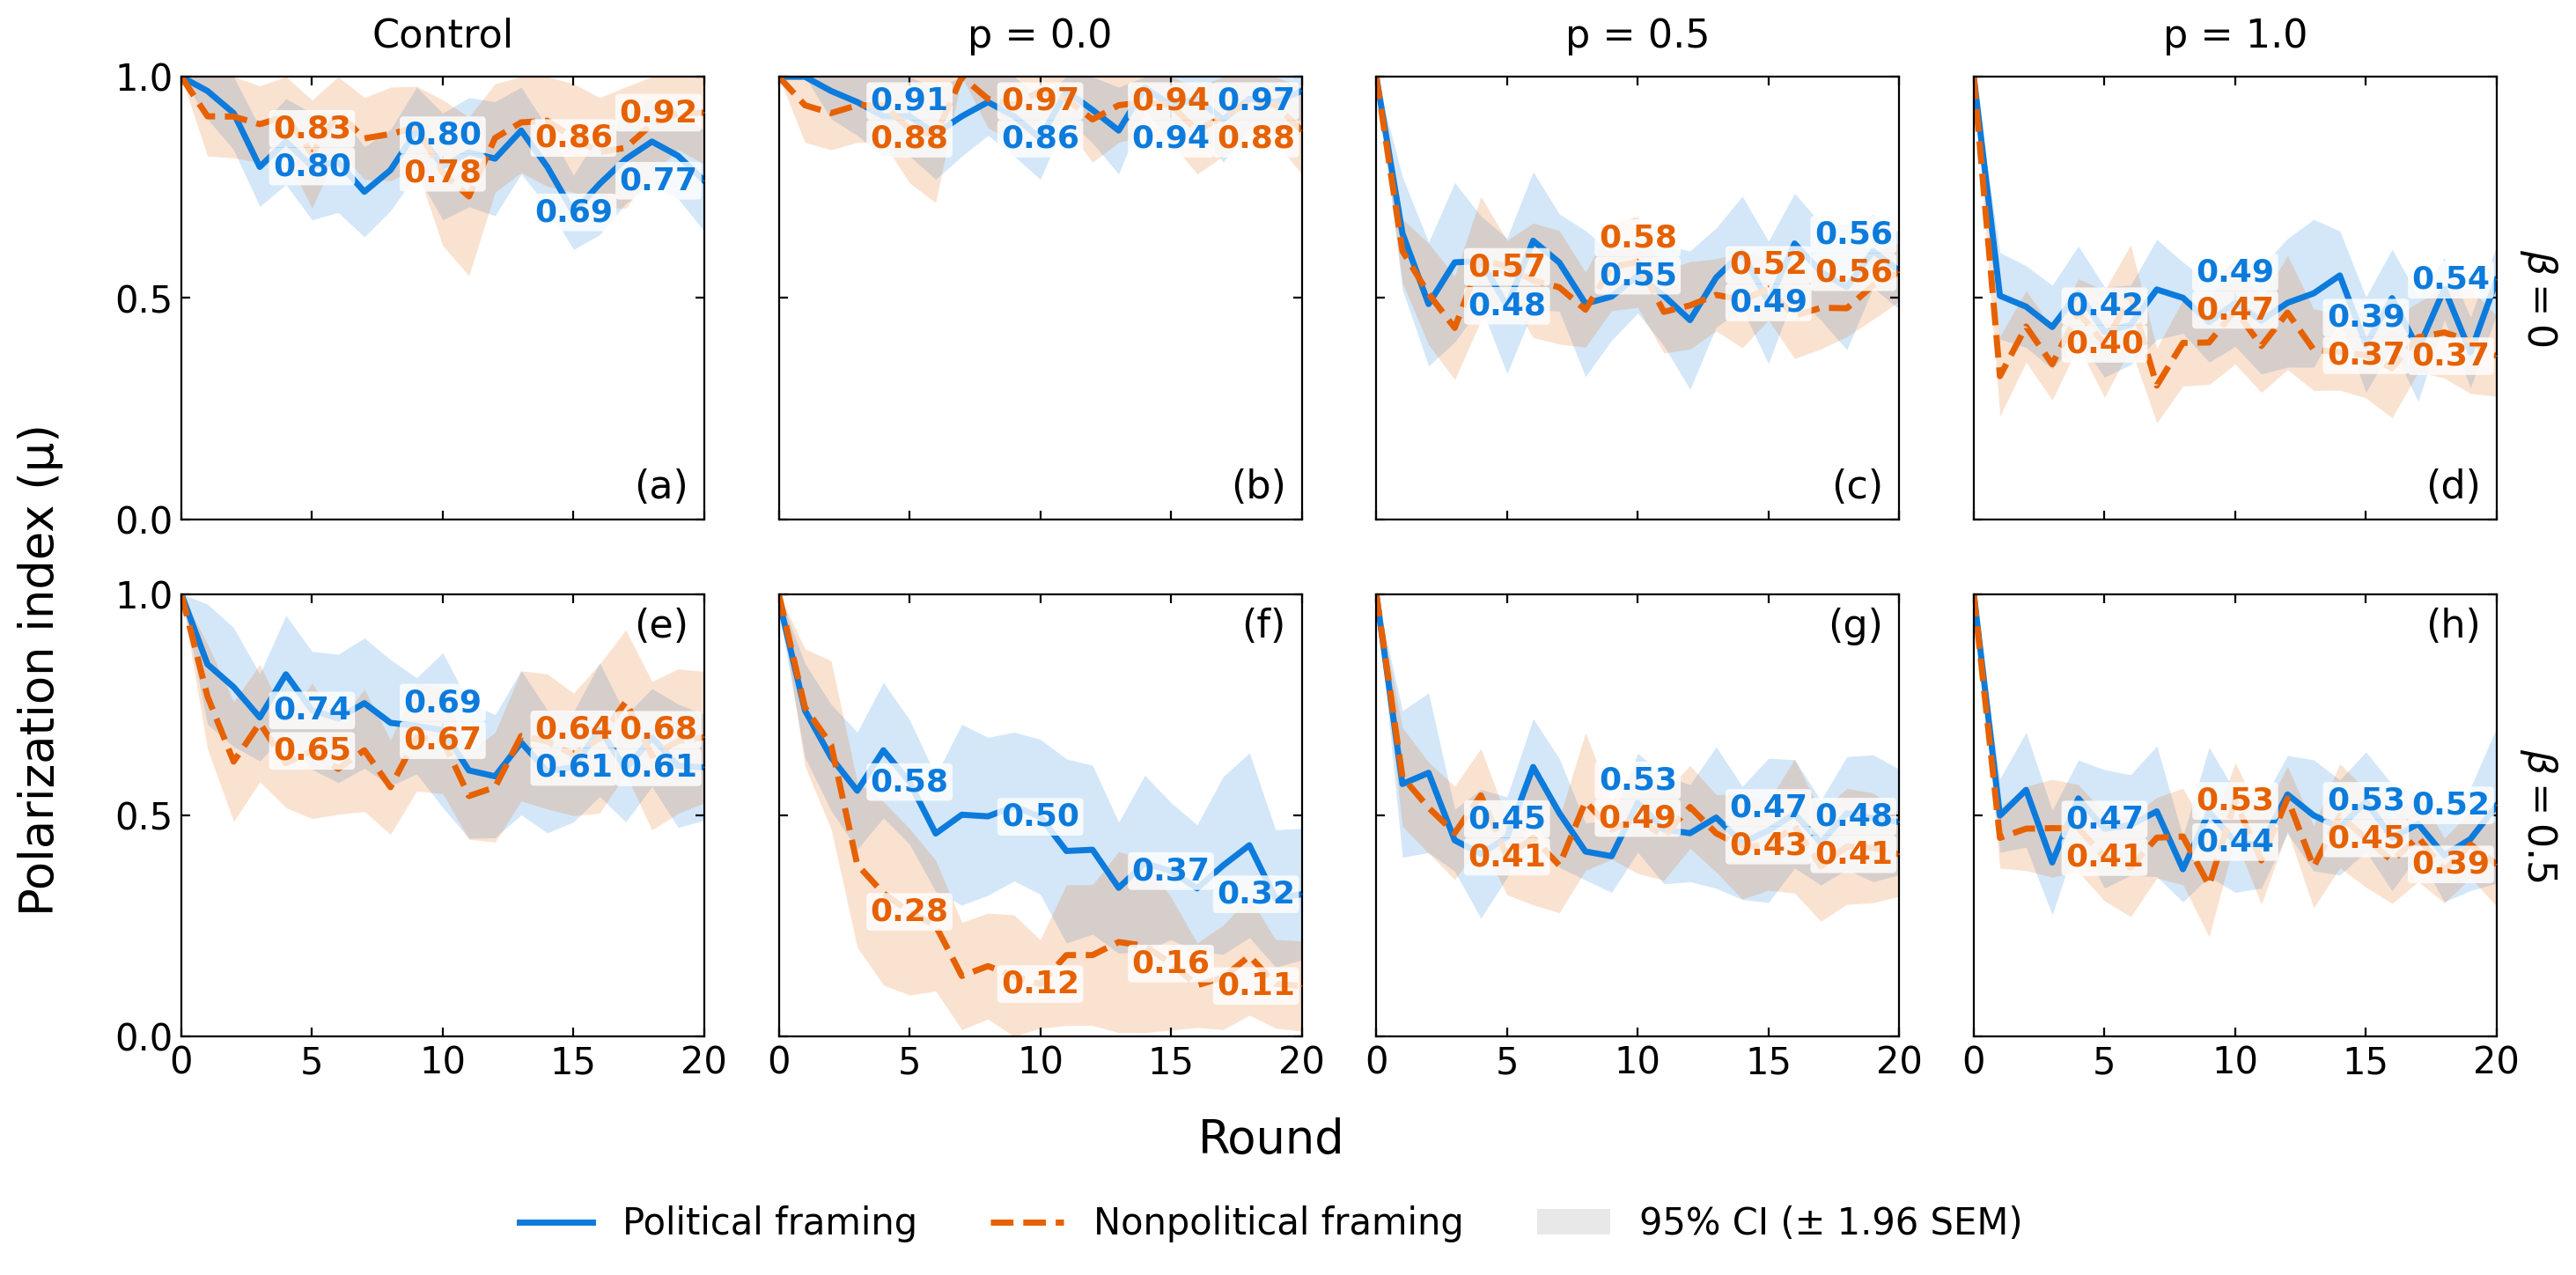

In [4]:
colors = {1: '#E66100', 2: '#0C7BDC'}
line_styles = {1: '--', 2: '-'}
framing_labels = {1: 'Nonpolitical framing', 2: 'Political framing'}
annotation_rounds = [5, 10, 15, 20]

def spread_annotation_positions(values, min_gap=0.085, lower=0.055, upper=0.945):
    ordered = sorted(values, key=values.get)
    positions = {framing: max(lower, min(upper, values[framing])) for framing in ordered}
    for previous, current in zip(ordered, ordered[1:]):
        positions[current] = max(positions[current], positions[previous] + min_gap)
    overflow = positions[ordered[-1]] - upper
    if overflow > 0:
        positions = {framing: position - overflow for framing, position in positions.items()}
    underflow = lower - positions[ordered[0]]
    if underflow > 0:
        positions = {framing: position + underflow for framing, position in positions.items()}
    return positions

plt.rcParams.update({
    'font.size': 15,
    'axes.labelsize': 19,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 15,
})
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)

for row, beta in enumerate(BETA_LEVELS):
    for col, p_anti in enumerate(P_ANTI_LEVELS):
        ax = axes[row, col]
        panel = polarization.loc[
            (polarization['beta'] == beta)
            & (polarization['p_anti'] == p_anti)
        ]

        trajectories = {}
        for framing in FRAMING_LEVELS:
            trajectory = panel.loc[panel['framing'] == framing].sort_values('round_no')
            trajectories[framing] = trajectory
            ax.fill_between(
                trajectory['round_no'], trajectory['ci_lower'], trajectory['ci_upper'],
                color=colors[framing], alpha=0.18, linewidth=0,
            )
            ax.plot(
                trajectory['round_no'], trajectory['mean_mu'],
                color=colors[framing], linewidth=2.5, linestyle=line_styles[framing],
            )

        for annotation_round in annotation_rounds:
            values = {
                framing: trajectories[framing].loc[
                    trajectories[framing]['round_no'] == annotation_round, 'mean_mu'
                ].iloc[0]
                for framing in FRAMING_LEVELS
            }

            label_positions = spread_annotation_positions(values)
            text_x = annotation_round - 0.25 if annotation_round == 20 else annotation_round
            horizontal_alignment = 'right' if annotation_round == 20 else 'center'
            for framing in FRAMING_LEVELS:
                ax.annotate(
                    f'{values[framing]:.2f}', xy=(annotation_round, values[framing]),
                    xytext=(text_x, label_positions[framing]), textcoords='data',
                    color=colors[framing], fontsize=13, fontweight='bold',
                    ha=horizontal_alignment, va='center', clip_on=True, zorder=5,
                    bbox=dict(boxstyle='round,pad=0.12', facecolor='white', edgecolor='none', alpha=0.82),
                    arrowprops=dict(arrowstyle='-', color=colors[framing], linewidth=0.7, alpha=0.8, shrinkA=1, shrinkB=1),
                )

        if row == 0:
            p_label = 'Control' if p_anti == 99 else f'p = {p_anti:.1f}'
            ax.set_title(p_label, fontsize=16, pad=12)
        panel_label = chr(ord('a') + row * len(P_ANTI_LEVELS) + col)
        panel_label_y = 0.03 if row == 0 else 0.97
        panel_label_va = 'bottom' if row == 0 else 'top'
        ax.text(
            0.97, panel_label_y, f'({panel_label})', transform=ax.transAxes,
            ha='right', va=panel_label_va, fontsize=16,
            fontweight='normal', zorder=10,
        )
        ax.set_xlim(plot_data['round_no'].min(), plot_data['round_no'].max())
        ax.set_ylim(0, 1)
        ax.set_yticks([0, 0.5, 1])
        ax.set_xticks(range(int(plot_data['round_no'].min()), int(plot_data['round_no'].max()) + 1, 5))
        ax.grid(False)
        ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
        for spine in ax.spines.values():
            spine.set_visible(True)
        if col == len(P_ANTI_LEVELS) - 1:
            ax.text(
                1.08, 0.5, rf'$\beta = {beta:g}$', transform=ax.transAxes,
                rotation=270, va='center', ha='center', fontsize=16,
            )

legend_handles = [
    Line2D(
        [0], [0], color=colors[framing], linewidth=2.5,
        linestyle=line_styles[framing], label=framing_labels[framing],
    )
    for framing in FRAMING_LEVELS
]
legend_handles.append(
    Patch(facecolor='0.5', alpha=0.18, edgecolor='none', label='95% CI (± 1.96 SEM)')
)
fig.legend(
    handles=legend_handles, loc='lower center', ncol=3, frameon=False,
    bbox_to_anchor=(0.5, 0.07),
)
fig.supxlabel('Round', fontsize=19, y=0.15)
fig.supylabel('Polarization index (μ)', fontsize=19, x=0.055)
fig.tight_layout(rect=(0.045, 0.12, 0.97, 0.99))
# fig.savefig('Figure_4.png', dpi=300, bbox_inches='tight')
plt.show()

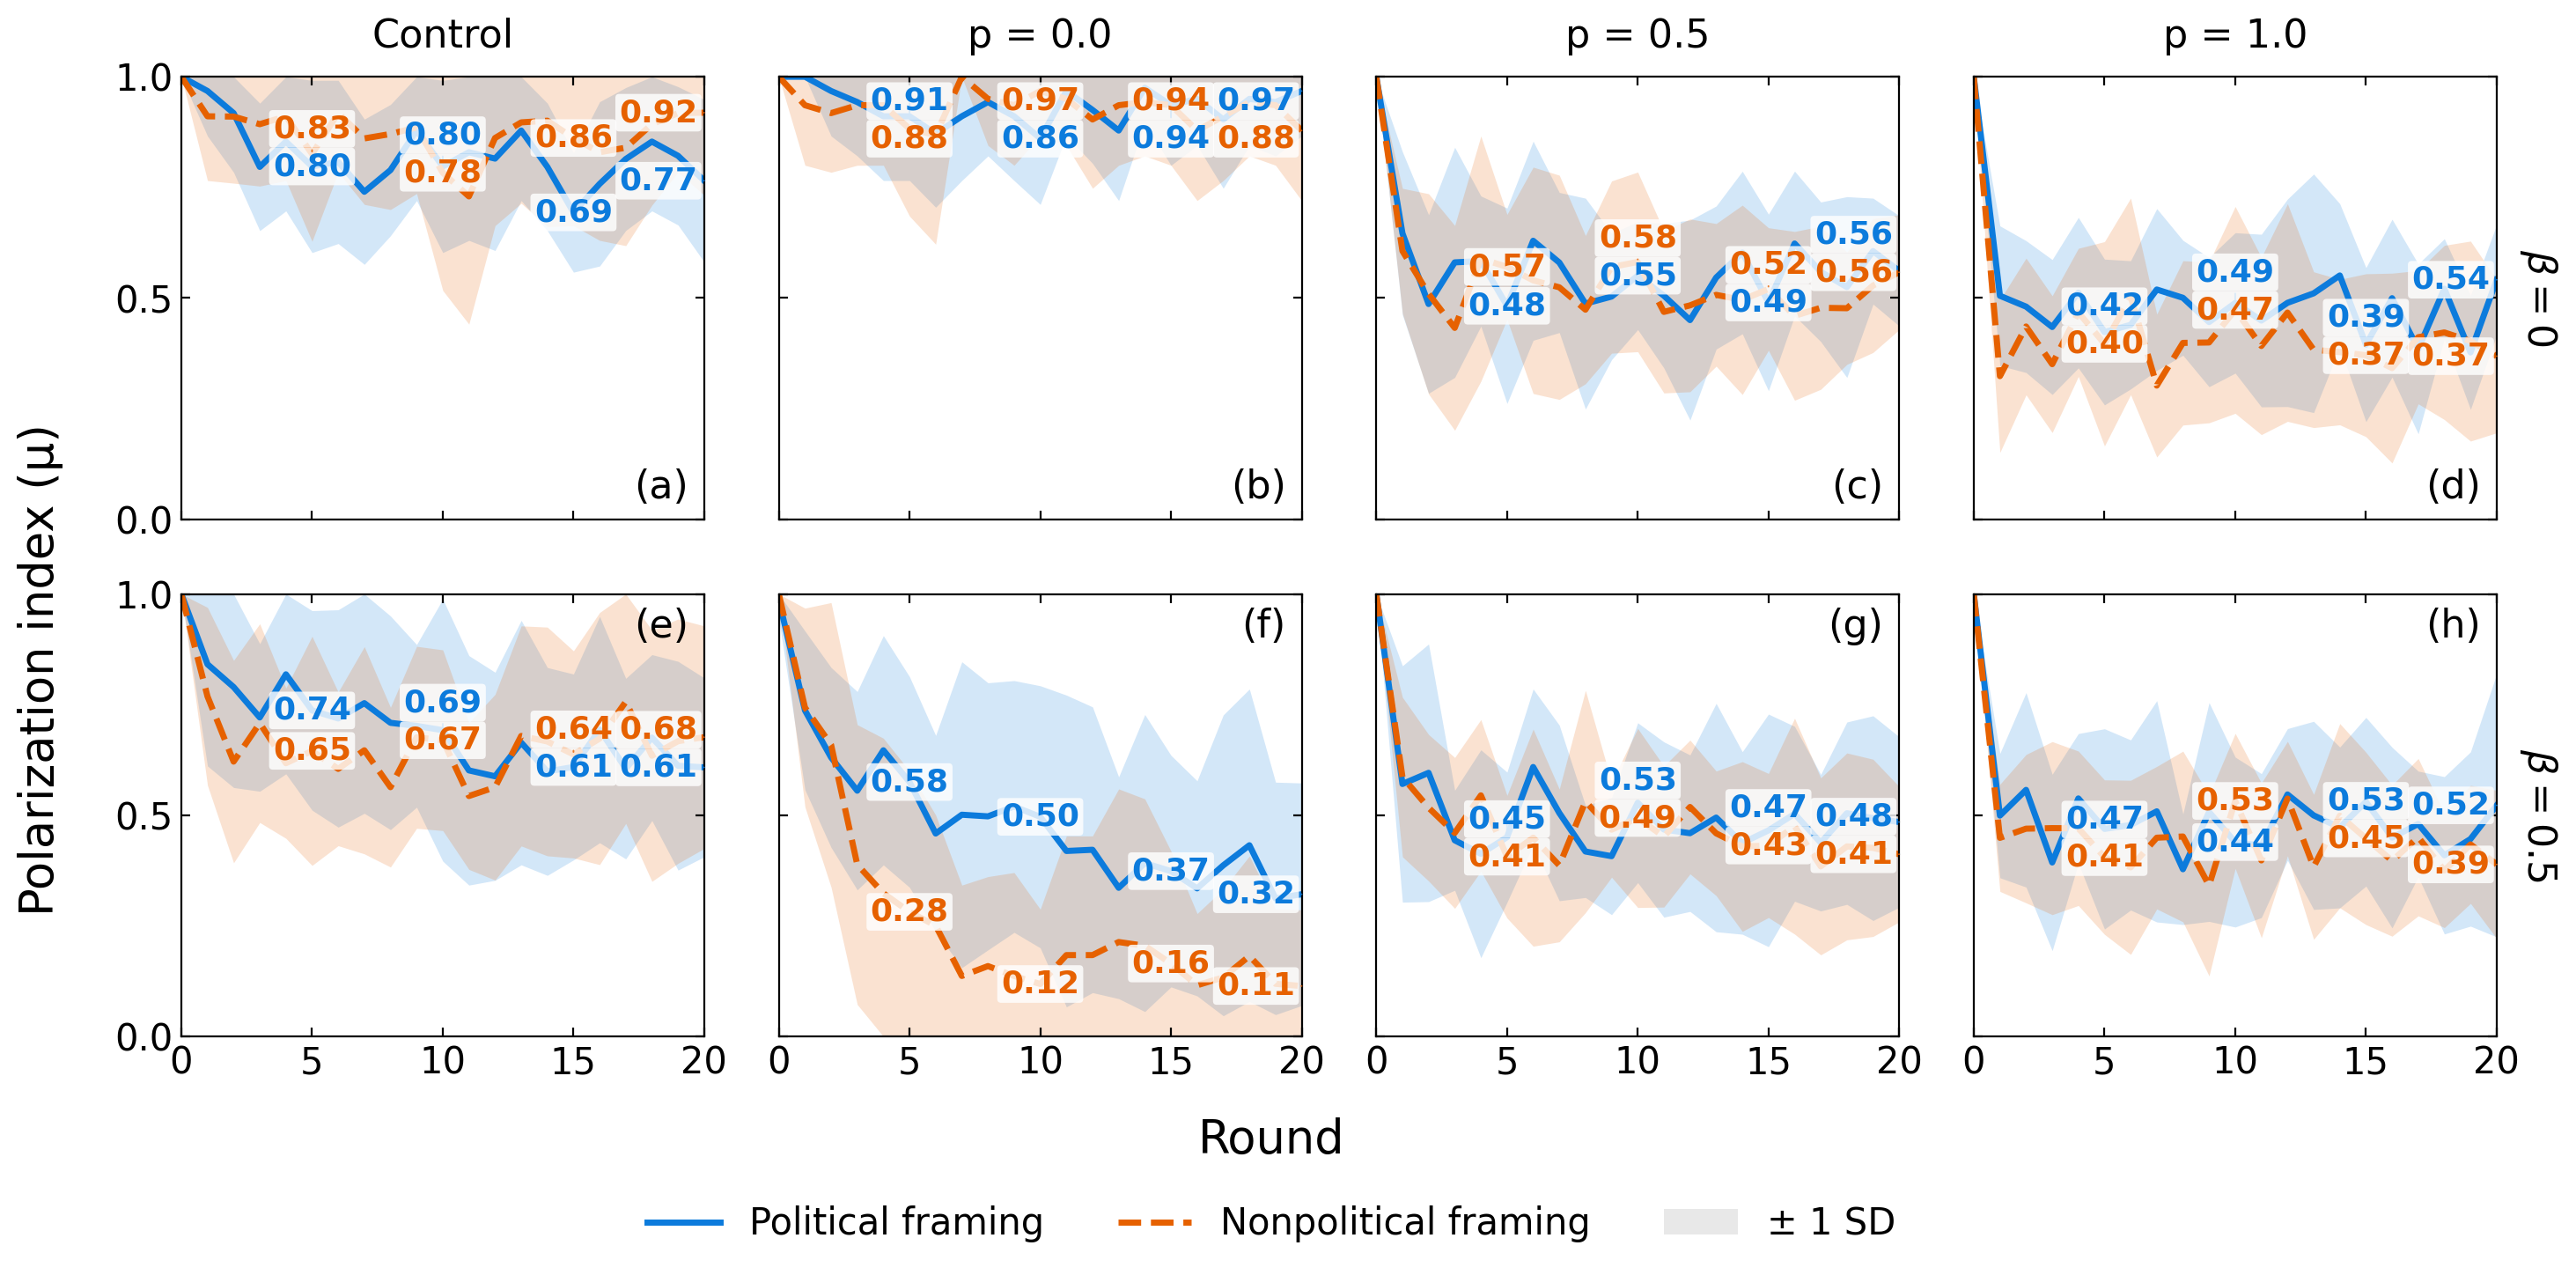

In [7]:
# Create the same polarization trajectories with mean ± 1 SD bands.
polarization_sd = (
    nid_fraction_table.reset_index()
    .groupby(
        ['framing', 'beta', 'p_anti', 'round_no'], as_index=False
    )
    .agg(
        mean_mu=('mu', 'mean'),
        sd_mu=('mu', 'std'),
        n_nid=('nid', 'nunique'),
    )
)
polarization_sd['sd_mu'] = polarization_sd['sd_mu'].fillna(0)
polarization_sd['sd_lower'] = (
    polarization_sd['mean_mu'] - polarization_sd['sd_mu']
).clip(lower=0)
polarization_sd['sd_upper'] = (
    polarization_sd['mean_mu'] + polarization_sd['sd_mu']
).clip(upper=1)
assert polarization_sd['mean_mu'].between(0, 1).all()

def plot_polarization_sd(summary, output_name):
    fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)

    for row, beta in enumerate(BETA_LEVELS):
        for col, p_anti in enumerate(P_ANTI_LEVELS):
            ax = axes[row, col]
            panel = summary.loc[
                (summary['beta'] == beta)
                & (summary['p_anti'] == p_anti)
            ]
            trajectories = {}
            for framing in FRAMING_LEVELS:
                trajectory = panel.loc[
                    panel['framing'] == framing
                ].sort_values('round_no')
                trajectories[framing] = trajectory
                ax.fill_between(
                    trajectory['round_no'], trajectory['sd_lower'],
                    trajectory['sd_upper'], color=colors[framing],
                    alpha=0.18, linewidth=0,
                )
                ax.plot(
                    trajectory['round_no'], trajectory['mean_mu'],
                    color=colors[framing], linewidth=2.5,
                    linestyle=line_styles[framing],
                )

            for annotation_round in annotation_rounds:
                values = {
                    framing: trajectories[framing].loc[
                        trajectories[framing]['round_no'] == annotation_round,
                        'mean_mu',
                    ].iloc[0]
                    for framing in FRAMING_LEVELS
                }
                label_positions = spread_annotation_positions(values)
                text_x = (
                    annotation_round - 0.25
                    if annotation_round == 20
                    else annotation_round
                )
                ha = 'right' if annotation_round == 20 else 'center'
                for framing in FRAMING_LEVELS:
                    ax.annotate(
                        f'{values[framing]:.2f}',
                        xy=(annotation_round, values[framing]),
                        xytext=(text_x, label_positions[framing]),
                        textcoords='data', color=colors[framing],
                        fontsize=13, fontweight='bold', ha=ha, va='center',
                        clip_on=True, zorder=5,
                        bbox=dict(
                            boxstyle='round,pad=0.12', facecolor='white',
                            edgecolor='none', alpha=0.82,
                        ),
                        arrowprops=dict(
                            arrowstyle='-', color=colors[framing],
                            linewidth=0.7, alpha=0.8, shrinkA=1, shrinkB=1,
                        ),
                    )

            if row == 0:
                p_label = 'Control' if p_anti == 99 else f'p = {p_anti:.1f}'
                ax.set_title(p_label, fontsize=16, pad=12)
            panel_label = chr(ord('a') + row * len(P_ANTI_LEVELS) + col)
            panel_label_y = 0.03 if row == 0 else 0.97
            panel_label_va = 'bottom' if row == 0 else 'top'
            ax.text(
                0.97, panel_label_y, f'({panel_label})',
                transform=ax.transAxes, ha='right', va=panel_label_va,
                fontsize=16, fontweight='normal', zorder=10,
            )
            ax.set_xlim(plot_data['round_no'].min(), plot_data['round_no'].max())
            ax.set_ylim(0, 1)
            ax.set_yticks([0, 0.5, 1])
            ax.set_xticks(
                range(
                    int(plot_data['round_no'].min()),
                    int(plot_data['round_no'].max()) + 1, 5,
                )
            )
            ax.grid(False)
            ax.tick_params(
                axis='both', which='both', direction='in', top=True, right=True
            )
            for spine in ax.spines.values():
                spine.set_visible(True)
            if col == len(P_ANTI_LEVELS) - 1:
                ax.text(
                    1.08, 0.5, rf'$\beta = {beta:g}$',
                    transform=ax.transAxes, rotation=270,
                    va='center', ha='center', fontsize=16,
                )

    legend_handles = [
        Line2D(
            [0], [0], color=colors[framing], linewidth=2.5,
            linestyle=line_styles[framing], label=framing_labels[framing],
        )
        for framing in FRAMING_LEVELS
    ]
    legend_handles.append(
        Patch(facecolor='0.5', alpha=0.18, edgecolor='none', label='± 1 SD')
    )
    fig.legend(
        handles=legend_handles, loc='lower center', ncol=3, frameon=False,
        bbox_to_anchor=(0.5, 0.07),
    )
    fig.supxlabel('Round', fontsize=19, y=0.15)
    fig.supylabel('Polarization index (μ)', fontsize=19, x=0.055)
    fig.tight_layout(rect=(0.045, 0.12, 0.97, 0.99))
    # fig.savefig(output_name, dpi=300, bbox_inches='tight')
    plt.show()

plot_polarization_sd(polarization_sd, 'Figure_4_sd.png')

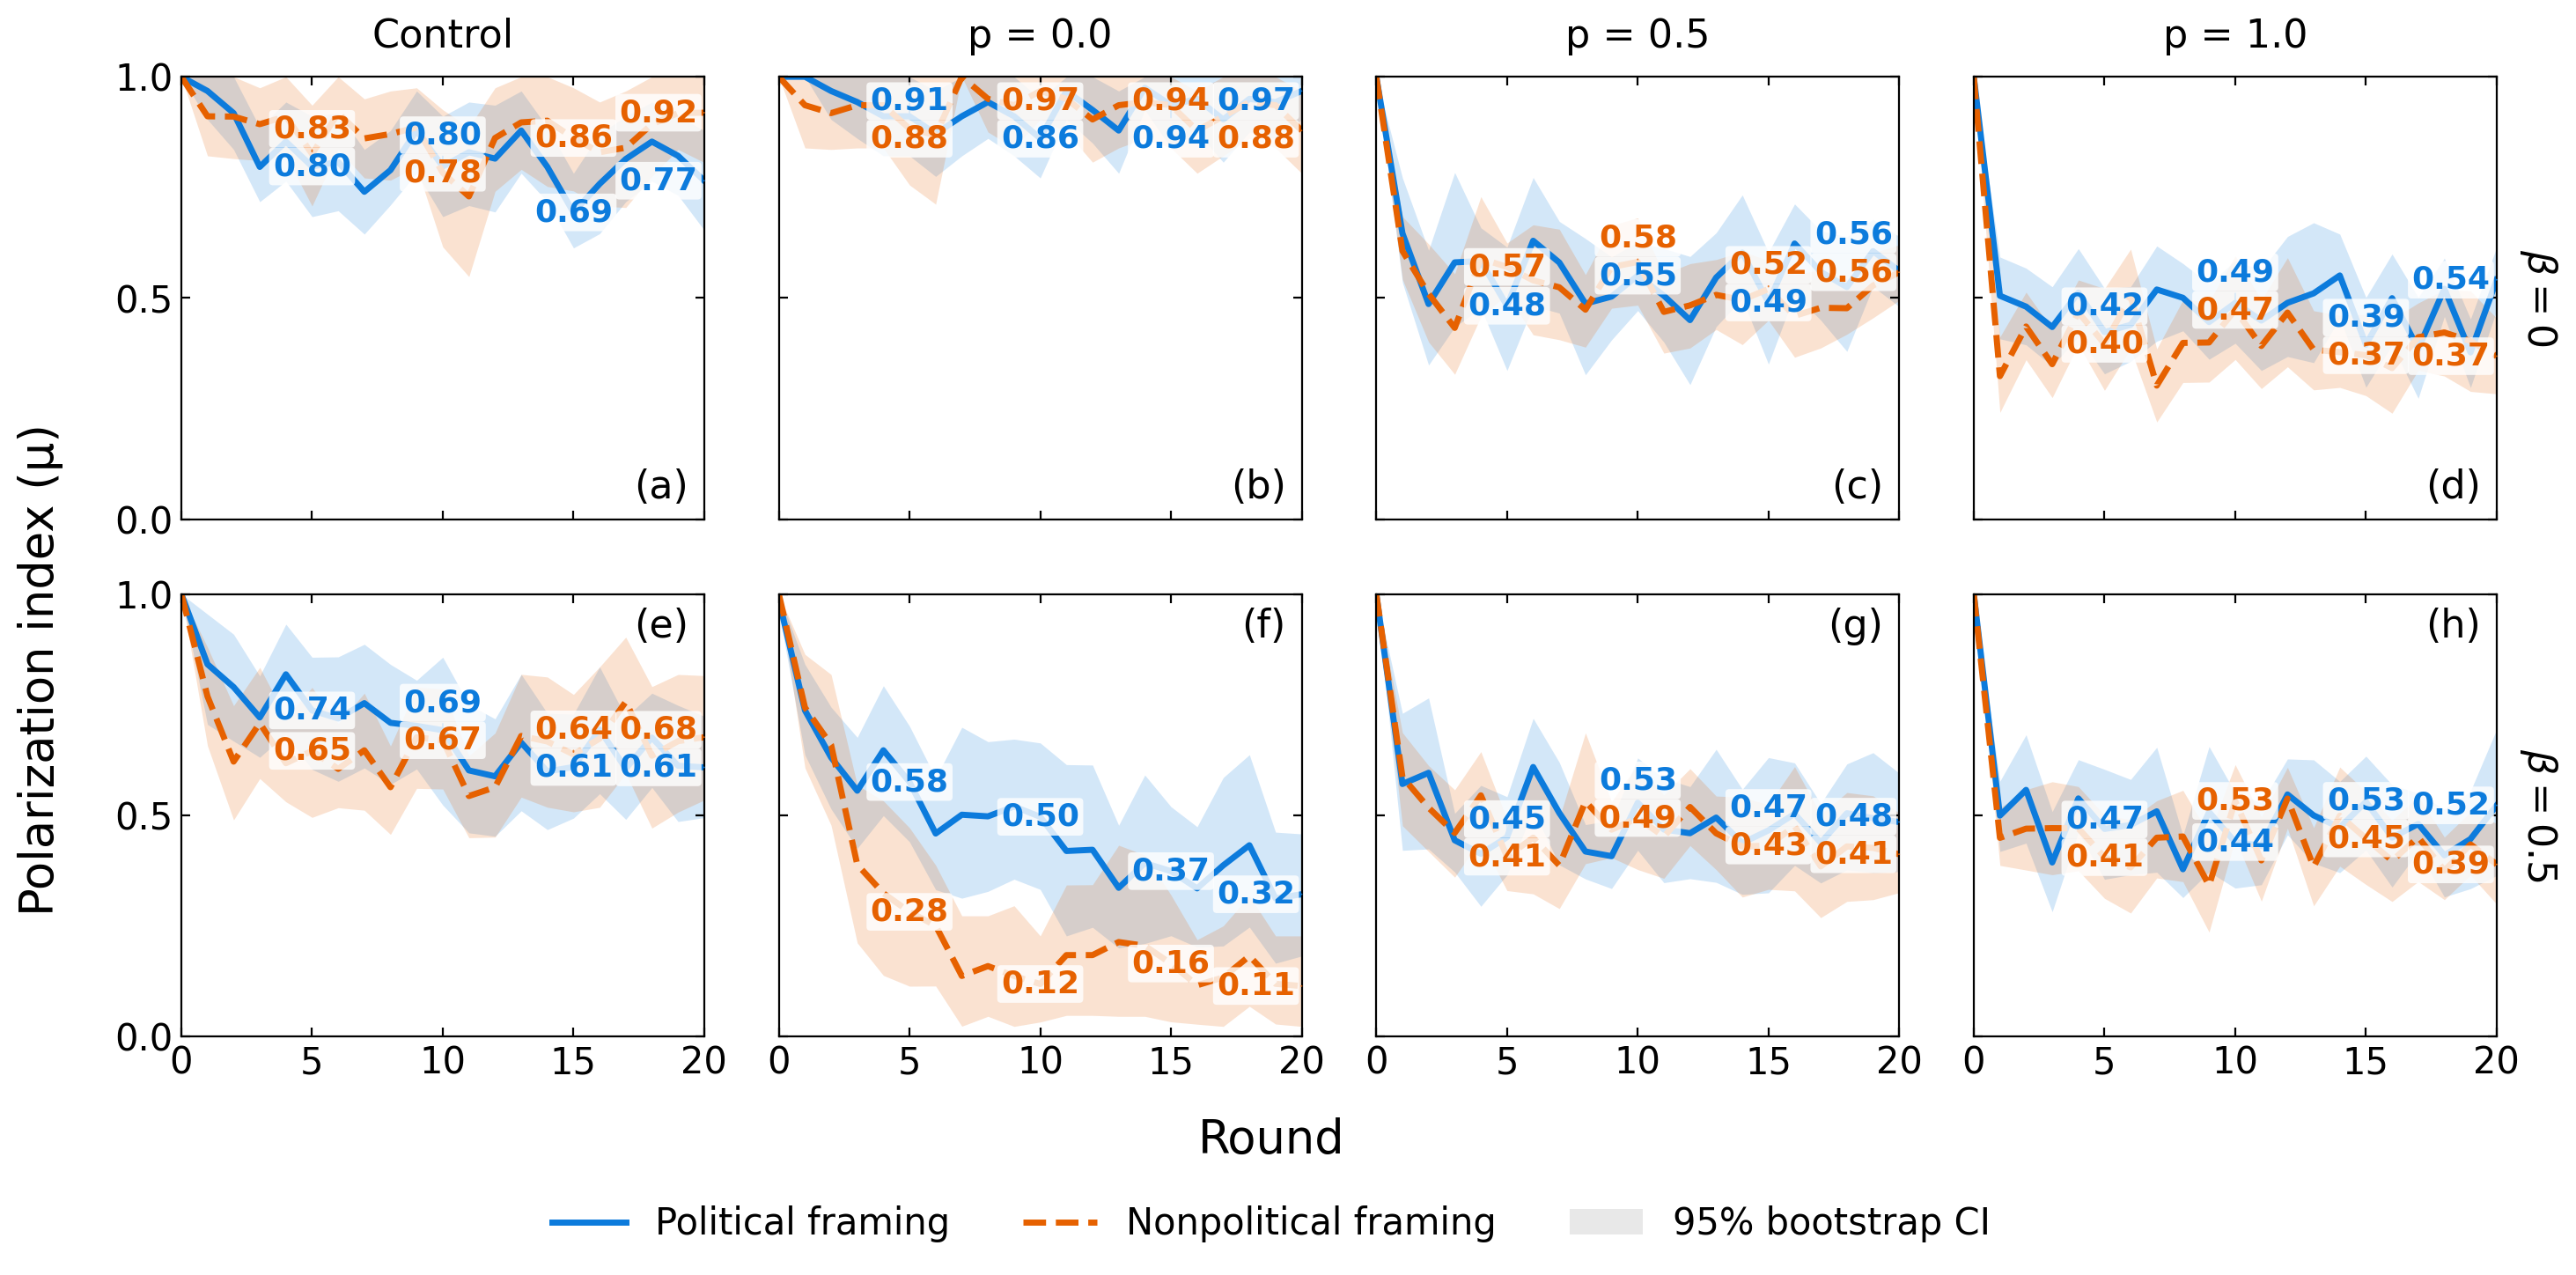

In [6]:
# Create the same polarization trajectories with 95% bootstrap confidence bands.
from bootstrap import bootstrap
import numpy as np

np.random.seed(20260715)
bootstrap_annotation_rounds = [5, 10, 15, 20]

records = []
nid_fraction_table_reset = nid_fraction_table.reset_index()
for group_values, group in nid_fraction_table_reset.groupby(
    ['framing', 'beta', 'p_anti', 'round_no'], sort=True
):
    lower, upper = bootstrap(group['mu'].to_numpy())
    records.append({
        **dict(zip(['framing', 'beta', 'p_anti', 'round_no'], group_values)),
        'mean_mu': group['mu'].mean(),
        'bootstr_ci_lower': lower,
        'bootstr_ci_upper': upper,
        'n_nid': group['nid'].nunique(),
    })
polarization_bootstr_ci = pd.DataFrame(records)
assert polarization_bootstr_ci['mean_mu'].between(0, 1).all()

def plot_polarization_bootstr_ci(summary, output_name):
    fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)

    for row, beta in enumerate(BETA_LEVELS):
        for col, p_anti in enumerate(P_ANTI_LEVELS):
            ax = axes[row, col]
            panel = summary.loc[
                (summary['beta'] == beta)
                & (summary['p_anti'] == p_anti)
            ]
            trajectories = {}
            for framing in FRAMING_LEVELS:
                trajectory = panel.loc[
                    panel['framing'] == framing
                ].sort_values('round_no')
                trajectories[framing] = trajectory
                ax.fill_between(
                    trajectory['round_no'],
                    trajectory['bootstr_ci_lower'],
                    trajectory['bootstr_ci_upper'],
                    color=colors[framing], alpha=0.18, linewidth=0,
                )
                ax.plot(
                    trajectory['round_no'], trajectory['mean_mu'],
                    color=colors[framing], linewidth=2.5,
                    linestyle=line_styles[framing],
                )

            for annotation_round in bootstrap_annotation_rounds:
                values = {
                    framing: trajectories[framing].loc[
                        trajectories[framing]['round_no'] == annotation_round,
                        'mean_mu',
                    ].iloc[0]
                    for framing in FRAMING_LEVELS
                }
                label_positions = spread_annotation_positions(values)
                text_x = (
                    annotation_round - 0.25
                    if annotation_round == bootstrap_annotation_rounds[-1]
                    else annotation_round
                )
                ha = (
                    'right'
                    if annotation_round == bootstrap_annotation_rounds[-1]
                    else 'center'
                )
                for framing in FRAMING_LEVELS:
                    ax.annotate(
                        f'{values[framing]:.2f}',
                        xy=(annotation_round, values[framing]),
                        xytext=(text_x, label_positions[framing]),
                        textcoords='data', color=colors[framing],
                        fontsize=13, fontweight='bold', ha=ha, va='center',
                        clip_on=True, zorder=5,
                        bbox=dict(
                            boxstyle='round,pad=0.12', facecolor='white',
                            edgecolor='none', alpha=0.82,
                        ),
                        arrowprops=dict(
                            arrowstyle='-', color=colors[framing],
                            linewidth=0.7, alpha=0.8, shrinkA=1, shrinkB=1,
                        ),
                    )

            if row == 0:
                p_label = 'Control' if p_anti == 99 else f'p = {p_anti:.1f}'
                ax.set_title(p_label, fontsize=16, pad=12)
            panel_label = chr(ord('a') + row * len(P_ANTI_LEVELS) + col)
            panel_label_y = 0.03 if row == 0 else 0.97
            panel_label_va = 'bottom' if row == 0 else 'top'
            ax.text(
                0.97, panel_label_y, f'({panel_label})',
                transform=ax.transAxes, ha='right', va=panel_label_va,
                fontsize=16, fontweight='normal', zorder=10,
            )
            ax.set_xlim(plot_data['round_no'].min(), plot_data['round_no'].max())
            ax.set_ylim(0, 1)
            ax.set_yticks([0, 0.5, 1])
            ax.set_xticks(
                range(
                    int(plot_data['round_no'].min()),
                    int(plot_data['round_no'].max()) + 1, 5,
                )
            )
            ax.grid(False)
            ax.tick_params(
                axis='both', which='both', direction='in', top=True, right=True
            )
            for spine in ax.spines.values():
                spine.set_visible(True)
            if col == len(P_ANTI_LEVELS) - 1:
                ax.text(
                    1.08, 0.5, rf'$\beta = {beta:g}$',
                    transform=ax.transAxes, rotation=270,
                    va='center', ha='center', fontsize=16,
                )

    legend_handles = [
        Line2D(
            [0], [0], color=colors[framing], linewidth=2.5,
            linestyle=line_styles[framing], label=framing_labels[framing],
        )
        for framing in FRAMING_LEVELS
    ]
    legend_handles.append(
        Patch(
            facecolor='0.5', alpha=0.18, edgecolor='none',
            label='95% bootstrap CI',
        )
    )
    fig.legend(
        handles=legend_handles, loc='lower center', ncol=3, frameon=False,
        bbox_to_anchor=(0.5, 0.07),
    )
    fig.supxlabel('Round', fontsize=19, y=0.15)
    fig.supylabel('Polarization index (μ)', fontsize=19, x=0.055)
    fig.tight_layout(rect=(0.045, 0.12, 0.97, 0.99))
    fig.savefig(output_name, dpi=300, bbox_inches='tight')
    plt.show()

plot_polarization_bootstr_ci(
    polarization_bootstr_ci, 'Figure_4_bootstr_ci.png'
)